# Datensatz LLM - Detect AI Generated Text Dataset

---

**Erstellt von:** Hasan Hüseyin Demirci, Andreas Hubertus, Sebastian Rein, Vitalii Solonychnyi  

**Modul:** Grundlagen Data Science und Künstliche Intelligenz 2

**Dozentin:** Prof. Dr. Jennifer Schoch  

**Hochschule:** Duale Hochschule Baden-Württemberg Karlsruhe

**Datum:** 

---

# Inhaltsverzeichnis
machen wir am ende

# 1. Business Understanding


#### 1.1 Motivation

In den letzten Jahren hat die rasante Entwicklung von Sprachmodellen und generativer Künstlicher Intelligenz zu einer zunehmenden Vermischung von KI-generierten und menschlich verfassten Texten geführt. Diese Entwicklung wirft zentrale Fragen hinsichtlich Authentizität, Transparenz und Verantwortung im digitalen Raum auf. Gerade in Bereichen wie Journalismus oder Social Media wird es immer wichtiger, die Herkunft von Texten zuverlässig zu erkennen, um Täuschung und Fehlinformationen zu vermeiden.

#### 1.2 Zielsetzung


Die Zentrale Forschungsfrage dieser Analyse lautet daher: 

*Wodurch unterscheiden sich KI-generierte von menschengeschriebenen Texten, und inwieweit lässt sich ein präzises Vorhersagemodell zur Unterscheidung beider entwickeln?*

Der Datensatz "AI Vs Human Text", der auf Kaggle zur Verfügung steht, ist hierfür die Grundlage. Er kann über folgenden Link aufgerufen, heruntergeladen und ausgelesen werden:

https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text/data


Die Analyse läuft auf Grundlage des CRISP-DM Prozesses, einem standardisierten Vorgehensmodell für Data-Science-Projekte.

Zu Beginn des Projekts wurde eine SMART-Zielsetzung festgelegt.

Ziel des Projekts ist es, bis zum 28.04.2026 ein Klassifikationsmodell zu entwickeln, das zwischen menschlich verfassten und KI-generierten Texten unterscheiden kann und auf dem Testdatensatz eine Genauigkeit von mindestens 90 % erreicht.

S – Spezifisch: Entwicklung eines Modells zur Unterscheidung zwischen menschlichen und KI-generierten Texten.

M – Messbar: Bewertung der Modellleistung anhand der Genauigkeit (Accuracy) auf dem Testdatensatz.

A – Achievable: Das Ziel ist realistisch, da ein ausreichend großer und balancierter Datensatz für Training und Evaluation zur Verfügung steht.

R – Relevant: Die Aufgabe steht im direkten Zusammenhang mit der zentralen Fragestellung des Projekts.

T – Time-bound: Umsetzung des Ziels bis zum 28.04.2026.

Langfristig soll diese Arbeit dazu beitragen, Vertrauen in digitale Inhalte zu stärken und Werkzeuge zu entwickeln, die eine transparente Nutzung von KI im Schreibprozess ermöglichen.

#### 1.3 Forschungsstand


Es gibt bereits einige Publikationen zu diesem Thema, beispielweise das Paper "Spotting LLMs With Binoculars: Zero-Shot Detection of Machine-Generated Text". Hier wird festgestellt, das sich heutige Sprachmodelle, obwohl sie sehr gut sind, immer noch in ihren statistischen Signaturen signifikant vom Menschen unterscheiden. Menschen würden oft intuitiv und unregelmäßig schreiben, die KI bewege sich stattdessen in einem sehr vorhersehbaren, mathematisch wahrscheinlichen Korridor.
Bereits 2019 kamen die Autoren des Papers "GLTR: Statistical Detection and Visualization of Generated Text." zu einem ähnlichen Schluss. LLMs verwendeten fast ausschließlich Worte mit sehr hohen Wahrscheinlichkeiten. Die generierten Texte seien dadruch sehr glatt, während Menschen regelmäßig Wörter streuen würden, die außerhalb der statistischen Erwartung eines Sprachmodells lägen.
Ein weiteres Merkmal von LLMs sei, so das Paper "Automatic Detection of Machine Generated Text: A Critical Survey.", dass die Texte der KI zwar innerhalb eines Satzes logisch klängen, aber bei mehreren Sätzen oft der rote Faden verloren gehe und sich selbst wiedersprochen würde. Generierte Texte würden plausibel klingen, erfänden aber oft Fakten (="Haluzinieren"), da sie nur Worte vorhersagen, statt auf echtes Wissen zurückzugreifen.
Aus diesen Forschungserkenntnissen wird klar, dass LLMs zwar Texte auf hohem Niveau produzieren, die abber eindeutig Unterschiede zu menschengeschriebenen Texten aufweisen.

Auf Kaggle ist neben dem ausgewählten Datensatz auch Code einsehbar, in dem User den Datensatz direkt implementieren. Im Code von User Yamin H wird erkenntlich, dass eine Textbereinigung der Rohdaten bei diesem Datenbestand essentiell ist, damit ein Modell die feinen Unterschiede in der Wortwahl präzise analysieren kann. Weitere Programme zeigen, dass es durchaus möglich ist, Prediction-Modelle mit Accuracys höher als 90% zu schaffen.

---

# 2. Data Understanding


## 2.1 Beschreibung des Korpus

Der vorliegende Datensatz besteht aus Texten, die entweder von Menschen verfasst oder durch ein KI-System generiert wurden. Ziel ist es, die strukturellen Eigenschaften des Korpus zu analysieren und ein grundlegendes Verständnis der Daten zu gewinnen.

Der Datensatz liegt in tabellarischer Form vor und enthält für jede Instanz mindestens einen Text sowie eine zugehörige Zielvariable. Insgesamt umfasst der Datensatz mehrere tausend Texte, die als Grundlage für die nachfolgende Analyse und Modellierung dienen.

Zur quantitativen Beschreibung des Korpus werden zwei zentrale Größen betrachtet:

- **Word Instances**: Gesamtanzahl aller Wörter im Korpus (inklusive Wiederholungen)  
- **Word Types**: Anzahl unterschiedlicher Wörter im Korpus  

Diese Kennzahlen geben Aufschluss über die Größe und Vielfalt des Vokabulars. Während die Anzahl der Word Instances die Gesamtmenge an Textinformation widerspiegelt, beschreibt die Anzahl der Word Types die lexikalische Diversität des Korpus.

Die folgende Analyse bestimmt diese Größen auf Basis einer einfachen Tokenisierung der Texte.

In [1]:
import pandas as pd
import re

# Datensatz laden
df = pd.read_csv("train.csv")

# Annahme: Text steht in Spalte "text"
texts = df["text"].astype(str)

# einfache Tokenisierung
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß ]", " ", text)
    tokens = text.split()
    return tokens

# alle Tokens sammeln
all_tokens = []

for text in texts:
    tokens = tokenize(text)
    all_tokens.extend(tokens)

# Word Instances (alle Wörter inkl. Wiederholungen)
word_instances = len(all_tokens)

# Word Types (einzigartige Wörter)
word_types = len(set(all_tokens))

print("Korpusstatistik:")
print(f"- Anzahl Texte: {len(df)}")
print(f"- Word Instances (Gesamtanzahl Wörter): {word_instances}")
print(f"- Word Types (einzigartige Wörter): {word_types}")

Korpusstatistik:
- Anzahl Texte: 20000
- Word Instances (Gesamtanzahl Wörter): 7711112
- Word Types (einzigartige Wörter): 48301


Für die folgende Analyse wird ein reduzierter und aufbereiteter Datensatz verwendet. 
Die detaillierte Beschreibung der Datensatzreduktion sowie der weiteren 
Datenvorbereitung erfolgt in Kapitel 3 (Data Preparation).

/var/folders/jc/lcd9d_6n4bg5qpdhp0ph_0dh0000gn/T/ipykernel_63318/1392223703.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_ai['tokens'].apply(len), df_human['tokens'].apply(len)], labels=['AI-generierte Texte', 'menschlich generierte Texte'])


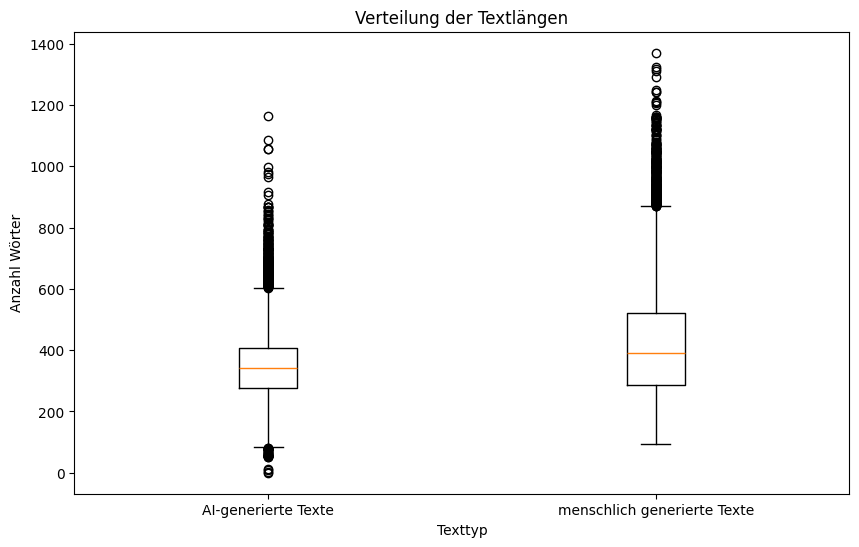

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

df_human = df[df['generated'] == 0].copy()
df_ai = df[df['generated'] == 1].copy()

top_n = 20
df_ai['tokens'] = df_ai['text'].str.lower().apply(lambda x: re.findall(r'\b\w+\b', str(x)))
df_human['tokens'] = df_human['text'].str.lower().apply(lambda x: re.findall(r'\b\w+\b', str(x)))

word_list_ai = np.concatenate(df_ai["tokens"].values)
word_list_human = np.concatenate(df_human["tokens"].values)

plt.figure(figsize=(10, 6))
plt.boxplot([df_ai['tokens'].apply(len), df_human['tokens'].apply(len)], labels=['AI-generierte Texte', 'menschlich generierte Texte'])
plt.title("Verteilung der Textlängen")
plt.xlabel("Texttyp")
plt.ylabel("Anzahl Wörter")
plt.show()

TODO: Das zu beschreiben

## 2.2 Zielvariable und Klassendefinition

Der vorliegende Datensatz beschreibt ein binäres Klassifikationsproblem zur Unterscheidung zwischen menschlich verfassten und KI-generierten Texten.

Die Trainingsdaten liegen in Form von Paaren $(x^{(i)}, y^{(i)})$ vor, wobei $x^{(i)}$ den jeweiligen Eingabetext und $y^{(i)}$ das zugehörige Klassenlabel bezeichnet.

Die Zielvariable ist binär kodiert und kann zwei Ausprägungen annehmen:

- $c_1 = 0$: menschlich verfasster Text  
- $c_2 = 1$: KI-generierter Text  

Somit ergibt sich für den Datensatz eine Anzahl von $k = 2$ Klassen. Ein Trainingsbeispiel besteht folglich jeweils aus einem Text sowie dem zugehörigen binären Label.

In [3]:
# Überblick über die Zielvariable
print("Spalten im Datensatz:")
print(df.columns.tolist())

print("\nAbsolute Häufigkeiten der Zielvariable:")
print(df["generated"].value_counts().sort_index())

print("\nRelative Häufigkeiten der Zielvariable:")
print(df["generated"].value_counts(normalize=True).sort_index())

print("\nAnzahl der Klassen:")
print(df["generated"].nunique())

print("\nEindeutige Klassenwerte:")
print(sorted(df["generated"].unique()))

Spalten im Datensatz:
['text', 'generated']

Absolute Häufigkeiten der Zielvariable:
generated
0    10000
1    10000
Name: count, dtype: int64

Relative Häufigkeiten der Zielvariable:
generated
0    0.5
1    0.5
Name: proportion, dtype: float64

Anzahl der Klassen:
2

Eindeutige Klassenwerte:
[np.int64(0), np.int64(1)]


## 2.3 Erste explorative Analyse (ohne Preprocessing)

Zur weiteren Untersuchung des Datensatzes wird eine explorative Analyse der Texte durchgeführt. Ziel ist es, grundlegende Unterschiede in der Wortverteilung zwischen menschlich verfassten und KI-generierten Texten zu identifizieren.

Hierzu werden die Texte zunächst in einzelne Wörter (Tokens) zerlegt. Anschließend werden für beide Klassen die Häufigkeiten der vorkommenden Wörter bestimmt. Auf Basis dieser Häufigkeiten werden die jeweils häufigsten Wörter extrahiert und visualisiert.

Die Analyse erfolgt ohne weitergehende Vorverarbeitungsschritte wie das Entfernen von Stopwords oder Normalisierung, um ein unverfälschtes Bild der Rohdaten zu erhalten.

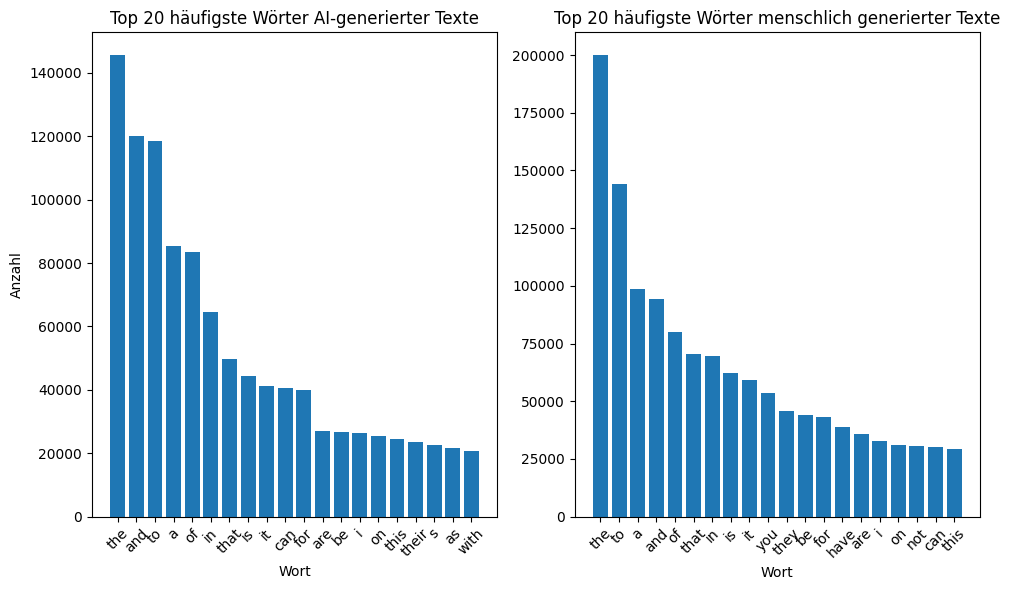

In [4]:
word_counts_ai = pd.Series(word_list_ai).value_counts()
word_counts_ai = word_counts_ai.reset_index()
word_counts_ai.columns = ["word", "count"]

word_counts_human = pd.Series(word_list_human).value_counts()
word_counts_human = word_counts_human.reset_index()
word_counts_human.columns = ["word", "count"]

top_words_ai = word_counts_ai.head(top_n)
top_words_human = word_counts_human.head(top_n)


plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.bar(top_words_ai["word"], top_words_ai["count"])
plt.title(f"Top {top_n} häufigste Wörter AI-generierter Texte")
plt.xlabel("Wort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(top_words_human["word"], top_words_human["count"])
plt.title(f"Top {top_n} häufigste Wörter menschlich generierter Texte")
plt.xlabel("Wort")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Die Ergebnisse zeigen, dass in beiden Klassen vor allem sehr häufige, allgemeine Wörter dominieren, wie beispielsweise "the", "to", "and" oder "a". Dabei handelt es sich überwiegend um funktionale Wörter, die unabhängig vom konkreten Inhalt der Texte häufig auftreten.

Ein Vergleich der beiden Klassen zeigt, dass die häufigsten Wörter weitgehend übereinstimmen. Zwar treten einzelne Unterschiede in der Rangfolge oder in spezifischen Wörtern (z. B. "you" oder "would" in menschlichen Texten) auf, jedoch sind diese Unterschiede insgesamt gering und nicht eindeutig trennscharf.

Dies deutet darauf hin, dass die reine Betrachtung der Rohwortfrequenzen nur begrenzt geeignet ist, um zwischen menschlich verfassten und KI-generierten Texten zu unterscheiden. Insbesondere überlagern häufige Funktionswörter mögliche inhaltliche Unterschiede.

Daher ist eine weitergehende Vorverarbeitung der Texte sinnvoll. Insbesondere die Entfernung von Stopwords kann dazu beitragen, inhaltlich relevantere Wörter stärker hervorzuheben. Diese Schritte werden im folgenden Kapitel (Data Preparation) durchgeführt.

# 3. Data Preparation

## 3.1 Datensatzreduktion und Klassenbalancierung

Der ursprüngliche Datensatz umfasst insgesamt 487.235 Texte. Für die vorliegende Analyse wurde daraus eine reduzierte Stichprobe erstellt, um den Rechenaufwand zu verringern und die Experimente effizient durchführen zu können.

Für den Trainingsdatensatz wurden 20.000 Texte ausgewählt. Diese Stichprobengröße stellt einen Kompromiss zwischen Rechenaufwand und ausreichender Datenbasis dar, um stabile und aussagekräftige Modelle zu trainieren.

Dabei wurde gezielt eine ausgeglichene Klassenverteilung hergestellt, sodass jeweils 10.000 menschlich verfasste und 10.000 KI-generierte Texte enthalten sind. Eine solche Klassenbalancierung ist wichtig, um Verzerrungen im Modell zu vermeiden und eine gleichmäßige Berücksichtigung beider Klassen sicherzustellen.

Zusätzlich wurde ein separater Testdatensatz mit 5.000 Texten erstellt, bestehend aus jeweils 2.500 Beispielen pro Klasse. Dieser Datensatz dient der Evaluation der Modelle auf zuvor ungesehenen Daten und ermöglicht eine objektive Bewertung der Modellleistung.

Die Aufteilung in Trainings- und Testdaten erfolgt durch zufällige Stichprobenziehung mit festem Zufallsseed, um die Reproduzierbarkeit der Ergebnisse sicherzustellen. Der folgende Code zeigt die konkrete Umsetzung der Datensatzaufbereitung.

```python
df = pd.read_csv("AI_Human.csv")

human = df[df["generated"] == 0]
ai = df[df["generated"] == 1]

train_human = human.sample(10000, random_state=42)
train_ai = ai.sample(10000, random_state=42)

train = pd.concat([train_human, train_ai]).sample(frac=1, random_state=42)

remaining_human = human.drop(train_human.index)
remaining_ai = ai.drop(train_ai.index)

test_human = remaining_human.sample(2500, random_state=42)
test_ai = remaining_ai.sample(2500, random_state=42)

test = pd.concat([test_human, test_ai]).sample(frac=1, random_state=42)

train.to_csv("train_data.csv", index=False)
test.to_csv("test_data.csv", index=False)

In [5]:
# Laden der vorbereiteten Datensätze
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Klassenverteilung überprüfen
print("\nKlassenverteilung (Train):")
print(train["generated"].value_counts())

print("\nKlassenverteilung (Test):")
print(test["generated"].value_counts())



Klassenverteilung (Train):
generated
1    10000
0    10000
Name: count, dtype: int64

Klassenverteilung (Test):
generated
0    2500
1    2500
Name: count, dtype: int64


Die Überprüfung zeigt, dass beide Datensätze die erwartete Größe sowie eine ausgeglichene Klassenverteilung aufweisen. Damit sind die Daten für die anschließende Modellierung geeignet.

## 3.2 Wortfrequenzanalyse (ohne Stopwords) 


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vitalii/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


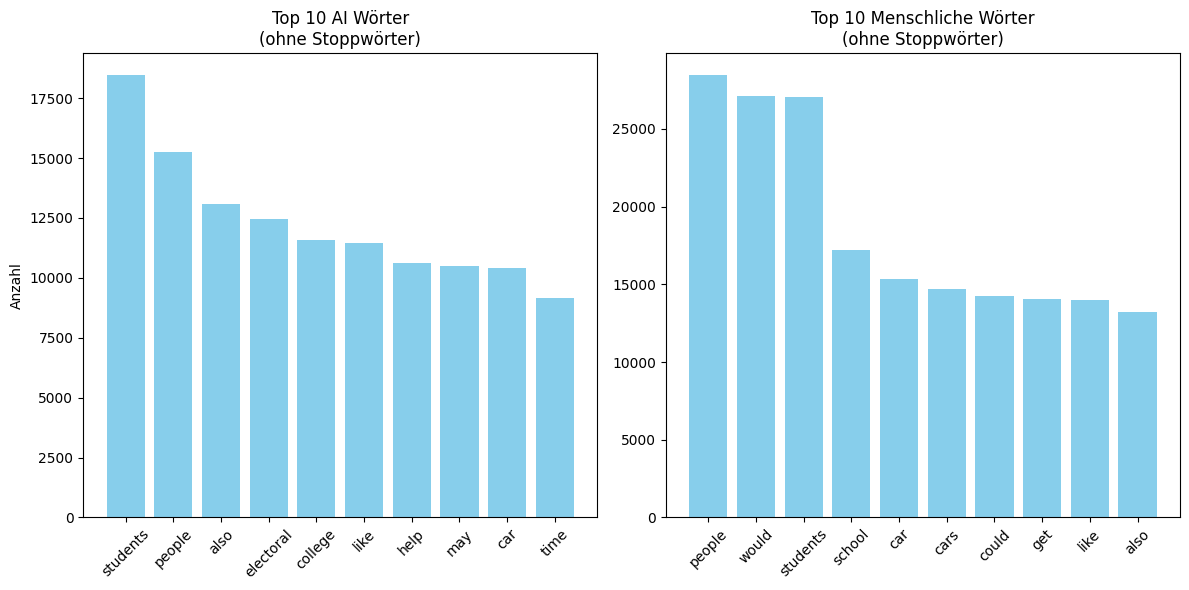

In [6]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

word_counts_ai_filtered = word_counts_ai[~word_counts_ai['word'].isin(stop_words)]
word_counts_human_filtered = word_counts_human[~word_counts_human['word'].isin(stop_words)]

top_n = 10 
top_words_ai_filtered = word_counts_ai_filtered.head(top_n)
top_words_human_filtered = word_counts_human_filtered.head(top_n)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(top_words_ai_filtered["word"], top_words_ai_filtered["count"], color='skyblue')
plt.title(f"Top {top_n} AI Wörter\n(ohne Stoppwörter)")
plt.xticks(rotation=45)
plt.ylabel("Anzahl")

plt.subplot(1, 2, 2)
plt.bar(top_words_human_filtered["word"], top_words_human_filtered["count"], color='skyblue')
plt.title(f"Top {top_n} Menschliche Wörter\n(ohne Stoppwörter)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TODO: Das Ding beschreiben

## 3.3 Vekrorisierung

### 3.3.1 Bag-of-Words Ansatz

Beschreiben, was aufgeffalen ist

### 3.3.2 TF-IDF Ansatz

### 3.3.3 N-gram Ansatz


Beim N-Gram-Ansatz werden Texte nicht nur in einzelne Wörter, sondern in Folgen von aufeinanderfolgenden Wörtern zerlegt. Ein Unigramm besteht aus einem Wort, ein Bigramm aus zwei Wörtern und ein Trigramm aus drei Wörtern. Dadurch können neben einzelnen Begriffen auch typische Wortfolgen als Merkmale erfasst werden.

Ziel dieses Abschnitts ist es, zu untersuchen, wie sich die Vektorisierung verändert, wenn verschiedene Werte für N verwendet werden.


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

texts = train["text"]

for n in [(1,1), (1,2), (1,3)]:
    vectorizer = CountVectorizer(stop_words="english", ngram_range=n, min_df=2)
    X = vectorizer.fit_transform(texts)
    
    print(f"N-gram-Bereich: {n}")
    print(f"Form der Matrix: {X.shape}")
    print(f"Anzahl Merkmale: {len(vectorizer.get_feature_names_out())}")
    print("Beispielmerkmale:", vectorizer.get_feature_names_out()[:20])
    print("-" * 50)


N-gram-Bereich: (1, 1)
Form der Matrix: (20000, 25431)
Anzahl Merkmale: 25431
Beispielmerkmale: ['00' '000' '0000' '001' '00am' '00pm' '01' '02' '03' '04' '05' '06' '07'
 '08' '09' '0f' '10' '100' '1000' '10000']
--------------------------------------------------
N-gram-Bereich: (1, 2)
Form der Matrix: (20000, 408915)
Anzahl Merkmale: 408915
Beispielmerkmale: ['00' '00 15' '00 22euro' '00 common' '00 dollar' '00 focus' '00 gas'
 '00 home' '00 need' '00 pm' '00 pocket' '000' '000 000' '000 001'
 '000 2000' '000 2009' '000 2019' '000 2020' '000 70' '000 able']
--------------------------------------------------
N-gram-Bereich: (1, 3)
Form der Matrix: (20000, 830910)
Anzahl Merkmale: 830910
Beispielmerkmale: ['00' '00 15' '00 15 half' '00 22euro' '00 22euro fine' '00 common'
 '00 common dinner' '00 dollar' '00 dollar fee' '00 focus'
 '00 focus classes' '00 gas' '00 gas week' '00 home' '00 need' '00 pm'
 '00 pm 11' '00 pm came' '00 pm completely' '00 pm picked']
----------------------------

Die Vektorisierung mit N-Grammen zeigt, dass die Anzahl der Merkmale mit wachsendem N stark zunimmt. Während bei der Verwendung von Unigrammen 25.431 Merkmale entstehen, steigt diese Zahl bei der Kombination aus Uni- und Bigrammen auf 408.915 und bei Uni-, Bi- und Trigrammen auf 830.910 Merkmale an. 

Auffällig ist vor allem der starke Anstieg der Merkmalsanzahl mit wachsendem N. Dadurch können mit Bigrammen und Trigrammen mehr sprachliche Zusammenhänge erfasst werden als mit Unigrammen. Gleichzeitig wird die Merkmalsmatrix deutlich größer, da sehr viele zusätzliche Wortfolgen als eigene Merkmale aufgenommen werden.

# 4. Modeling

Der Datensatz besteht aus einer Input- und einer Outputvariable:
Die Input-Variable ist ein String mit einem Text, die Output-Variable ist die Einschätzung, ob der Text von einem Menschen oder einer KI geschrieben wurde. Dies wird in Form einer Zahl ausgedrückt, mit 0 für menschengeschrieben und 1 für KI-verfasst.
Da die Zielvariable nur diskrete Klassen annimmt ist, handelt es sich eindeutig um eine Klassifikationsaufgabe.
Eine gute Predictionfrage wäre daher: 
*Wie hoch ist die Wahrscheinlichkeit, dass ein gegebener Text von einer KI und nicht von einem Menschen geschrieben wurde?*

Eine Frage zur Inference ist:
*Welche Texteigenschaften (z.B. Satzlänge, Wortvielfalt, Perplexity) stehen statistisch in Zusammenhang damit, ob ein Text von einer KI oder von einem Menschen verfasst wurde?*



## 4.1 Bag-of-Words Ansatz

## 4.2 TF-IDF Ansatz

## 4.3 N-gram Ansatz

# 5. Evaluation

Graphick f1 Score

f1 von alle Modelle speichern und dann in 5. Evaluation graphisch darstellen

Optional:
If/Else Zuordung, len...

[] Löschen



# Literaturverzeichnis

[1] Gehrmann et al. (2019). *GLTR: Statistical Detection and Visualization of Generated Text.*  
https://arxiv.org/abs/1906.04043

[2] Hans et al. (2024). *Spotting LLMs With Binoculars: Zero-Shot Detection of Machine-Generated Text.*  
https://arxiv.org/abs/2401.12070

[3] Jawahar et al. (2020). *Automatic Detection of Machine Generated Text: A Critical Survey.*  
https://arxiv.org/abs/2001.01314

[4] Yamin H (2024). *AI Text Cleaning & Preprocessing Guide. Kaggle Notebook.*
https://www.kaggle.com/code/yaminh/ai-text-cleaning
